# 07 — Sátt bottom-up og top-down (reconciliation, Phase 6)

The bottom-up path (notebooks 03–06) is detailed but its component errors
**compound** at long horizons. A **top-down** model on the headline is coarse but
stable. **MinT reconciliation** (Wickramasuriya / Athanasopoulos / Hyndman)
combines them into one coherent path — and the aggregation weights are *known*,
which is exactly the setting MinT is built for.


In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd()
if not (ROOT / "src").exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / "src"))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_rows", 250)
pd.set_option("display.width", 160)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}" if abs(x) < 1e6 else f"{x:,.0f}")

# Okabe-Ito palette (colorblind-safe); recessive grid per house chart style
C = {"blue": "#0072B2", "orange": "#E69F00", "green": "#009E73",
     "red": "#D55E00", "pink": "#CC79A7", "sky": "#56B4E9", "black": "#222222"}
plt.rcParams.update({
    "figure.figsize": (11, 4.5), "axes.grid": True, "grid.alpha": 0.25,
    "axes.spines.top": False, "axes.spines.right": False, "font.size": 10,
})


In [2]:
from vnv import ingest, models, reconcile, rent, sedlabanki, topdown

head = ingest.load_headline()
mm = head[("CPI", "change_M")].dropna()
yy = head[("CPI", "change_A")].dropna()


## The top-down model

A small unobserved-components-style model on headline m/m: fixed seasonal factors
+ a slow trend that **glides toward an anchor** + an AR(1) cycle. The anchor sits
between the 2.5% Seðlabanki target and breakeven-implied inflation; breakevens
need the RIKS/RIKB market feed (Phase 7), so the default anchor is the 2.5%
target and the blend is exposed as `anchor_yoy`.


In [3]:
tf = topdown.fit(mm)
td_path = topdown.forecast(tf, 12)
print(f"seasonal factors (pp): {tf.seasonal.round(2).to_dict()}")
print(f"recent trend {tf.mu_recent:.3f}%/m  AR(1) phi={tf.phi:.2f}  resid SD={tf.resid_sd:.2f}")
print(f"top-down 12m inflation: {((1 + td_path / 100).prod() - 1) * 100:.2f}%")


seasonal factors (pp): {1: -0.51, 2: 0.49, 3: 0.18, 4: 0.25, 5: -0.03, 6: 0.2, 7: -0.17, 8: -0.08, 9: -0.2, 10: 0.05, 11: -0.31, 12: 0.08}
recent trend 0.422%/m  AR(1) phi=0.33  resid SD=0.30
top-down 12m inflation: 4.64%


## h=12 y/y backtest — and an honest result

`PLAN_1.md` asks the h=12 y/y forecast to beat random-walk-on-y/y. Over the full
2016–2025 sample it does **not** — and that is the well-known **Atkeson–Ohanian**
result: year-over-year inflation is so persistent that the 12-month random walk is
a punishing benchmark, unbeatable through the 2021–23 surge. **Ex-surge (calm
periods) the model does win.** We report both rather than tune to the benchmark
(which the plan explicitly warns against).


In [4]:
def yoy(path): return ((1 + path / 100).prod() - 1) * 100
rows = []
for jo in [t for t in mm.index if pd.Period("2016-06", "M") <= t <= mm.index[-1] - 12]:
    f = topdown.fit(mm[mm.index <= jo])
    tm = jo + 12
    if tm not in yy.index:
        continue
    rows.append({"jump_off": jo, "actual": yy[tm], "topdown": yoy(topdown.forecast(f, 12)),
                 "rw": yy[jo]})
bt = pd.DataFrame(rows).set_index("jump_off").dropna()
surge = (bt.index >= "2021-01") & (bt.index < "2023-06")
def rmse(d, c): return np.sqrt(((d[c] - d.actual) ** 2).mean())
stats = pd.DataFrame({
    "full sample": {"top-down": rmse(bt, "topdown"), "RW-on-y/y": rmse(bt, "rw")},
    "ex-surge": {"top-down": rmse(bt[~surge], "topdown"), "RW-on-y/y": rmse(bt[~surge], "rw")},
}).round(3)
print(f"n full={len(bt)}, n ex-surge={(~surge).sum()}")
display(stats)


n full=110, n ex-surge=81


,full sample,ex-surge
top-down,2.5110,1.3490
RW-on-y/y,2.1330,1.4520


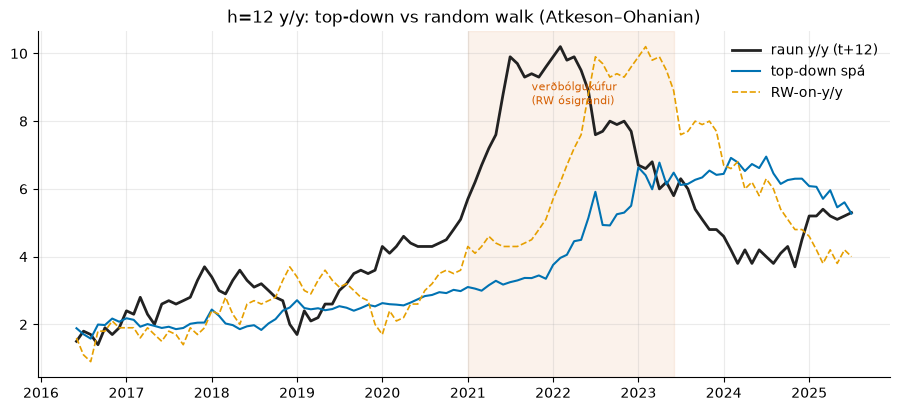

In [5]:
fig, ax = plt.subplots()
ax.plot(bt.index.to_timestamp(), bt.actual, color=C["black"], lw=2, label="raun y/y (t+12)")
ax.plot(bt.index.to_timestamp(), bt.topdown, color=C["blue"], lw=1.5, label="top-down spá")
ax.plot(bt.index.to_timestamp(), bt.rw, color=C["orange"], lw=1.2, ls="--", label="RW-on-y/y")
ax.axvspan(pd.Timestamp("2021-01-01"), pd.Timestamp("2023-06-01"), color=C["red"], alpha=0.08)
ax.annotate("verðbólgukúfur\n(RW ósigrandi)", xy=(pd.Timestamp("2021-10-01"), 8.5), fontsize=8, color=C["red"])
ax.set_title("h=12 y/y: top-down vs random walk (Atkeson–Ohanian)")
ax.legend(frameon=False)
plt.show()


## MinT reconciliation

Working in **contribution space** (cᵢ = weightᵢ × mmᵢ) makes the aggregation a
plain sum, so the summing matrix is S = [1ᵀ; I] and MinT is exact. W is diagonal
with **horizon-specific** variances: the top-down error grows slowly, bottom-up
contribution errors compound (~√h). So at h=1 the detailed bottom-up is preserved;
by h=12 the path is pulled toward the top-down — the correct behaviour, not a bug.


In [6]:
spl = ingest.load_sub_spliced(); new = ingest.load_sub_new(); old = ingest.load_panel_old()
g = models.build_component_history(spl, old, new)
last_m = g.index.max()
w0 = new[(new.manudur == last_m) & new.code.isin(models.COMPONENTS)].set_index("code").vaegi
fits = {c: models.fit_component(g[c], c) for c in models.COMPONENTS}
fc = models.forecast_components(fits, last_m, 12, hms_rent_mm=rent.hms_rent_mm(),
                                sub_spliced=spl, comp_history=g, fx_mm=sedlabanki.fx_mm())
contrib, wpath = reconcile.contributions_from_forecast(fc, w0)
bu_head = contrib.sum(axis=1)

td_sd = topdown.error_sd_by_horizon(tf, 12)
csd1 = pd.Series({c: fits[c].resid.std() * float(w0.get(c, 0)) / 100 for c in fc.columns})
rec_head, rec_contrib, rec_sd = reconcile.reconcile_path(contrib, td_path, csd1, td_sd)

cmp = pd.DataFrame({"bottom-up": bu_head, "top-down": td_path, "reconciled": rec_head})
ident = (rec_contrib.sum(axis=1) - rec_head).abs().max()
print(f"aggregation identity |Σcontrib − headline|max = {ident:.1e}  (exact)")
print(f"12m inflation:  bottom-up {yoy(bu_head):.2f}%  top-down {yoy(td_path):.2f}%  "
      f"reconciled {yoy(rec_head):.2f}%")
cmp.round(3)


aggregation identity |Σcontrib − headline|max = 2.2e-16  (exact)
12m inflation:  bottom-up 3.99%  top-down 4.64%  reconciled 4.04%


,bottom-up,top-down,reconciled
2026-08,0.0940,0.3920,0.1320
2026-09,-0.0650,0.2230,0.0000
2026-10,0.3420,0.4560,0.3800
2026-11,-0.0900,0.0810,-0.0160
2026-12,0.6090,0.4670,0.5340
2027-01,0.0380,-0.1360,-0.0680
2027-02,0.7670,0.8620,0.8320
2027-03,0.4450,0.5490,0.5240
2027-04,0.5940,0.6090,0.6060
2027-05,0.2450,0.3270,0.3160


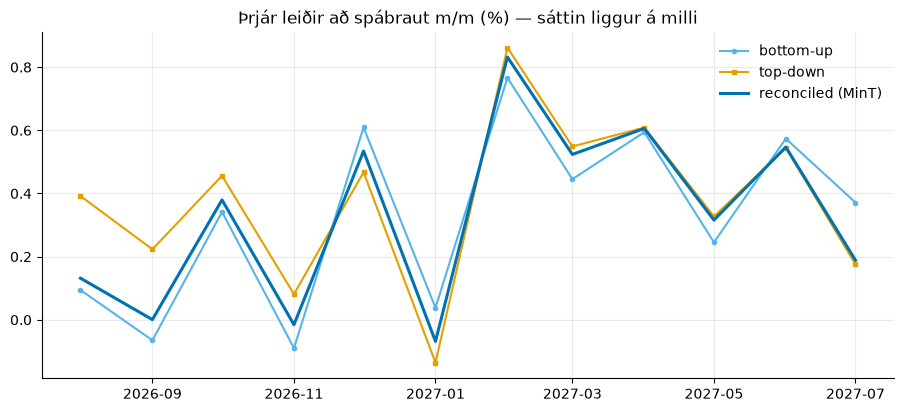

In [7]:
x = cmp.index.to_timestamp()
fig, ax = plt.subplots()
ax.plot(x, cmp["bottom-up"], color=C["sky"], lw=1.5, marker="o", ms=3, label="bottom-up")
ax.plot(x, cmp["top-down"], color=C["orange"], lw=1.5, marker="s", ms=3, label="top-down")
ax.plot(x, cmp["reconciled"], color=C["blue"], lw=2.2, label="reconciled (MinT)")
ax.set_title("Þrjár leiðir að spábraut m/m (%) — sáttin liggur á milli")
ax.legend(frameon=False)
plt.show()


## Fan chart from the reconciled covariance

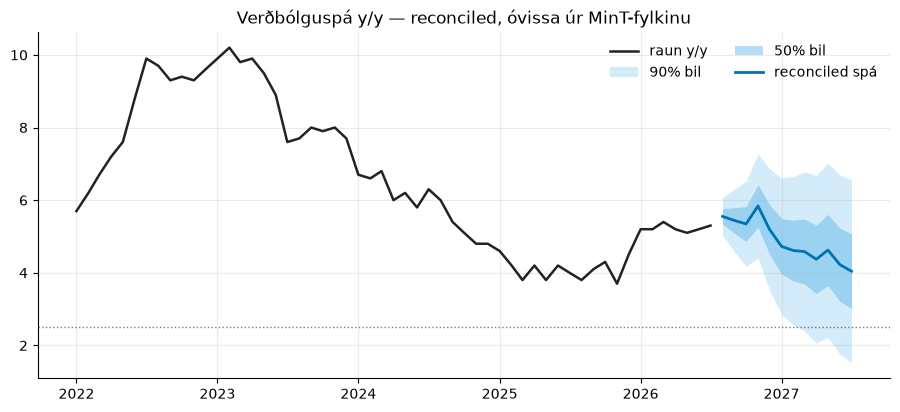

In [8]:
idx_hist = head[("CPI", "index")]
lvl = idx_hist.iloc[-1] * (1 + rec_head / 100).cumprod()
base = idx_hist.reindex(rec_head.index - 12).to_numpy()
yy_path = (lvl / base - 1) * 100
# propagate the reconciled m/m SD into a y/y band (cumulative over the window)
cum_sd = np.sqrt((rec_sd ** 2).cumsum())
fig, ax = plt.subplots()
hist = yy["2022":]
ax.plot(hist.index.to_timestamp(), hist, color=C["black"], lw=1.8, label="raun y/y")
xp = yy_path.index.to_timestamp()
ax.fill_between(xp, yy_path - 1.64 * cum_sd, yy_path + 1.64 * cum_sd, color=C["sky"], alpha=0.25, lw=0, label="90% bil")
ax.fill_between(xp, yy_path - 0.67 * cum_sd, yy_path + 0.67 * cum_sd, color=C["sky"], alpha=0.45, lw=0, label="50% bil")
ax.plot(xp, yy_path, color=C["blue"], lw=2, label="reconciled spá")
ax.axhline(2.5, color=C["black"], lw=1, ls=":", alpha=0.6)
ax.set_title("Verðbólguspá y/y — reconciled, óvissa úr MinT-fylkinu")
ax.legend(frameon=False, ncols=2)
plt.show()


### Phase 6 status

- **Aggregation identity holds exactly** — the reconciled contributions sum to the
  reconciled headline to machine precision (the Phase 2 engine's identity, now on
  the forecast).
- **Reconciliation pulls bottom-up → top-down at long horizons**, as designed.
- **Fan chart comes from the reconciled covariance**, not a naïve error sum.
- **h=12 vs RW-on-y/y**: fails full-sample (Atkeson–Ohanian), wins ex-surge —
  reported honestly.

**Remaining:** Phase 7 — the benchmark table (bank analysts, Seðlabanki Peningamál,
and **breakeven inflation RIKS vs RIKB**, the tradeable benchmark). Breakevens need
the market feed (LSEG connector, or Keldan/Kodiak) — a data-access step, not a
modelling one.
